# Hong Kong: corrected ridge forecasting study

Original: `legacy/notebooks/HONG KONG RIDGE LOG (4).ipynb`. The original is preserved unchanged. This executable counterpart uses the shared deployment implementation; it is a corrected experiment, not a claim that the original results were reproduced.

**Critical corrections:** Removed current-target rolling leakage and the deletion of 2020–2022 before shifts. Scaling now fits separately inside each training window.

## Forecasting contract and reasoning

Predict the next **12 monthly arrival counts from one fixed origin**, with no intervening actual observations. Keep the complete calendar, including pandemic months: deleting rows changes the meaning of lags. Model log1p arrivals so zero is defined; invert with expm1. This inversion is not an unbiased conditional-mean estimate. Never clip evaluation targets or impute missing targets. Only past arrival lags and known calendar terms are permitted; external predictors are excluded because their publication timing is not established.

All seven candidates use identical annual splits. Ridge α ∈ {1,10,100} is selected temporally, with scaling fit on training rows only. Random forest uses a fixed seed and modest fixed settings; XGBoost likewise uses 200 depth-3 trees, learning rate 0.05 and regularization, without holdout tuning. These choices limit the search and establish reproducible comparisons, not optimality.

In [1]:
from pathlib import Path
import sys

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "stis/config.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from stis.config import CANDIDATES, CITIES
from stis.io import load_city_raw
from stis.features import make_features
from stis.evaluate import evaluate_city, validation_origins
from stis.artifacts import load_bundle, source_fingerprints
from app.values import forecast_view


In [2]:
CITY = 'Hong Kong'
FOCUS_MODELS = ['ridge_1', 'ridge_10', 'ridge_100']
frame = load_city_raw(CITY)
print("Input:", CITIES[CITY]["file"])
print(CITIES[CITY]["note"])
print("Rows:", len(frame), "| Data:", frame.date.min().date(), "to", frame.date.max().date())
print("Python:", sys.executable)
display(frame.describe(include="all"))


Input: hongkong_2015_2024_final_filled.csv
The supplied file is labelled 'filled'; upstream imputation methods are undocumented.
Rows: 120 | Data: 2015-01-01 to 2024-12-01
Python: /Users/aman/Documents/Codex/2026-09-30/take-ownership-of-upgrading-this-entire/work/venv/bin/python


,date,visitor_arrivals
count,120,1.200000e+02
mean,2019-12-16 10:48:00,3.152184e+06
min,2015-01-01 00:00:00,1.800000e+03
25%,2017-06-23 12:00:00,7.690225e+04
50%,2019-12-16 12:00:00,3.965588e+06
75%,2022-06-08 12:00:00,4.977120e+06
max,2024-12-01 00:00:00,6.784406e+06
std,NaN,2.214691e+06


## Prove features cannot see the current or future target

Changing every target from a chosen month onward must leave that month's feature row unchanged. The deployed feature function is tested directly below. The first twelve rows are warm-up rows; they are not removed before constructing calendar lags.

In [3]:
cut = 60
original_features = make_features(frame)
altered = frame.copy()
altered.loc[cut:, "visitor_arrivals"] += 1234567
pd.testing.assert_series_equal(original_features.iloc[cut], make_features(altered).iloc[cut])
assert np.isclose(original_features.loc[cut, "log_lag12"], np.log1p(frame.loc[cut - 12, "visitor_arrivals"]))
assert np.isclose(original_features.loc[cut, "log_roll3"], np.log1p(frame.loc[cut-3:cut-1, "visitor_arrivals"]).mean())
print("PASS: feature causality and calendar lag/rolling identities.")


PASS: feature causality and calendar lag/rolling identities.


## Chronological model selection, then an untouched reporting year

Six expanding annual windows (2018–2023 for this supplied dataset) select lowest mean MAE. Each window recursively predicts all twelve months without using that year's actuals as later lags. The final year (2024) is excluded from model selection and hyperparameter fitting. It is a reporting holdout; this audit already exposed its outcomes, so it cannot be claimed as a fresh blind experiment. After evaluation, refit on all available observations to forecast January–December 2025. Newer data is required for a current forecast.

In [4]:
development = frame.iloc[:-12]
plan = []
for stop in validation_origins(len(development)):
    plan.append({"train_end": development.date.iloc[stop-1], "test_start": development.date.iloc[stop], "test_end": development.date.iloc[stop+11]})
display(pd.DataFrame(plan))
print("Reporting holdout:", frame.date.iloc[-12].date(), "to", frame.date.iloc[-1].date())


,train_end,test_start,test_end
0,2017-12-01,2018-01-01,2018-12-01
1,2018-12-01,2019-01-01,2019-12-01
2,2019-12-01,2020-01-01,2020-12-01
3,2020-12-01,2021-01-01,2021-12-01
4,2021-12-01,2022-01-01,2022-12-01
5,2022-12-01,2023-01-01,2023-12-01


Reporting holdout: 2024-01-01 to 2024-12-01


## Recompute the experiment

This cell actually refits and evaluates all candidates using the same backend as deployment. The family-specific choice below uses validation MAE only. The overall deployment choice can be another family, including a simple baseline. No improvement over the original notebooks is claimed because their protocols and sometimes targets differ.

In [5]:
result = evaluate_city(frame)
leaderboard = pd.DataFrame(result["leaderboard"]).sort_values("validation_mae")
focus_choice = leaderboard.loc[leaderboard.model.isin(FOCUS_MODELS), "model"].iloc[0]
print("Family validation choice:", CANDIDATES[focus_choice])
print("Overall validation choice:", CANDIDATES[result["selected_model"]])
display(leaderboard)
reported = pd.DataFrame(result["holdout_metrics"])
display(reported.loc[reported.model.isin(list(dict.fromkeys(FOCUS_MODELS + ["snaive", "naive"]))), ["model", "mae", "rmse", "wape_pct", "r2", "mase", "guardrail_months", "band_coverage_pct"]])


Family validation choice: Ridge · α = 100
Overall validation choice: Random forest


,model,validation_mae,folds
5,rf,1.314181e+06,6
6,xgb,1.329457e+06,6
1,naive,1.345085e+06,6
4,ridge_100,1.457092e+06,6
0,snaive,1.590401e+06,6
3,ridge_10,3.344905e+06,6
2,ridge_1,3.697681e+06,6


,model,mae,rmse,wape_pct,r2,mase,guardrail_months,band_coverage_pct
0,snaive,8.752606e+05,1.292785e+06,23.601054,-8.094977,0.698464,0,100.0
1,naive,4.015418e+05,4.824801e+05,10.827414,-0.266799,0.320433,0,100.0
2,ridge_1,1.257303e+06,1.466282e+06,33.902675,-10.699945,1.003337,0,100.0
3,ridge_10,1.564490e+06,1.724093e+06,42.185858,-15.175971,1.248475,0,100.0
4,ridge_100,2.286853e+06,2.363075e+06,61.664086,-29.388125,1.824926,0,100.0


## Interpret metrics without disguising errors

MAE and RMSE are in arrivals; WAPE is sum absolute error / sum actual arrivals ×100. WAPE is not an accuracy percentage. Negative R² means worse squared error than the evaluation year's mean, and is retained. MASE uses the training seasonal-naïve scale. Zero denominators return unavailable values, never fabricated zeros. Cross-city errors should not be ranked by raw MAE because cities have different scales. Validation includes unusual pandemic periods and cannot guarantee future performance.

In [6]:
score = reported.set_index("model").loc[focus_choice]
print(f"{CANDIDATES[focus_choice]} reporting holdout MAE: {score.mae:,.2f} arrivals")
print("Reporting holdout WAPE (%):", score.wape_pct)
print("Reporting holdout R²:", score.r2)
if score.r2 < 0:
    print("Negative R²: worse squared error than the holdout mean; this is not hidden or relabelled as accuracy.")


Ridge · α = 100 reporting holdout MAE: 2,286,853.05 arrivals
Reporting holdout WAPE (%): 61.664085519208015
Reporting holdout R²: -29.38812510067837
Negative R²: worse squared error than the holdout mean; this is not hidden or relabelled as accuracy.


## Twelve-month forecast and deployment reconciliation

The ML recursion has a disclosed numerical bound of 0–2× the training maximum. This is an operational heuristic, not a domain-derived physical limit; affected months are flagged. Error reference bands pool 72 validation errors (finite-sample 80% order statistic). They are **not calibrated prediction intervals**: dependence, selection and regime changes invalidate a guaranteed coverage claim. Main plots show point estimates only.

The deployment bundle was built on macOS, while CI uses Linux. Tree implementations may produce slightly different floating-point results across those environments, even with fixed seeds and one worker. Reconciliation therefore allows up to 0.1% relative difference for RF/XGBoost monthly forecasts and 1% for their validation MAEs. The latter is a diagnostic tolerance for error scores, not a claim about forecasting accuracy. Naïve, seasonal naïve and Ridge keep strict tolerances. All models must still have identical dates and the same validation-selected winner.

,date,forecast,forecast_arrivals,guardrail_applied
0,2025-01-01,2.742500e+06,2742500,False
1,2025-02-01,2.304906e+06,2304906,False
2,2025-03-01,2.065676e+06,2065676,False
3,2025-04-01,1.845392e+06,1845392,False
4,2025-05-01,1.695171e+06,1695171,False
5,2025-06-01,1.665087e+06,1665087,False
6,2025-07-01,1.567400e+06,1567400,False
7,2025-08-01,1.514610e+06,1514610,False
8,2025-09-01,1.484122e+06,1484122,False
9,2025-10-01,1.417426e+06,1417426,False


Displayed 12-month total: 20,877,132
Monthly average of displayed estimates: 1739761.0
Highest / lowest: 2742500 / 1241266


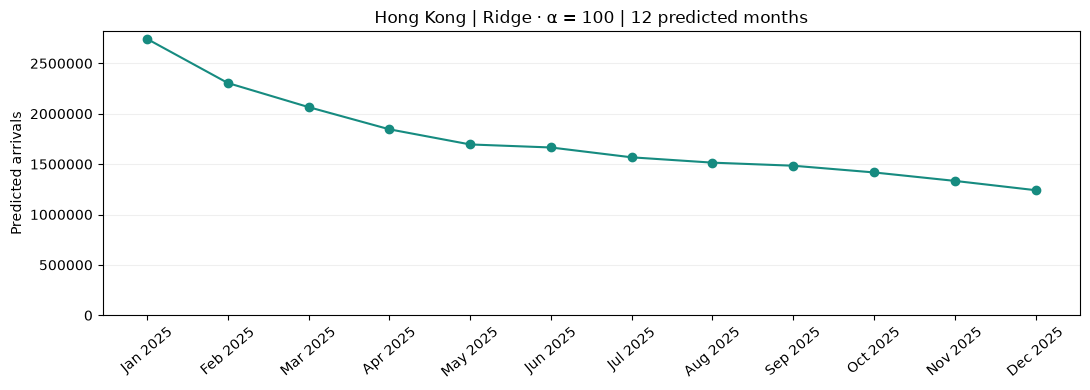

In [7]:
outlook, summary = forecast_view(result["outlook"], focus_choice, result["data_end"])
display(outlook[["date", "forecast", "forecast_arrivals", "guardrail_applied"]])
print("Displayed 12-month total:", f"{summary['total']:,}")
print("Monthly average of displayed estimates:", summary["average"])
print("Highest / lowest:", summary["maximum"], "/", summary["minimum"])
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(outlook.date.dt.strftime("%b %Y"), outlook.forecast_arrivals, marker="o", color="#168B80")
ax.set(title=f"{CITY} | {CANDIDATES[focus_choice]} | 12 predicted months", ylabel="Predicted arrivals")
ax.tick_params(axis="x", rotation=40)
ax.ticklabel_format(axis="y", style="plain")
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()
plt.close(fig)


In [8]:
published = load_bundle()["cities"][CITY]
assert result["selected_model"] == published["selected_model"]
for candidate in CANDIDATES:
    computed, _ = forecast_view(result["outlook"], candidate, result["data_end"])
    deployed, _ = forecast_view(published["outlook"], candidate, published["data_end"])
    tree_model = candidate in ("rf", "xgb")
    forecast_rtol = 1e-3 if tree_model else 1e-8
    score_rtol = 1e-2 if tree_model else 1e-8
    np.testing.assert_allclose(computed.forecast, deployed.forecast, rtol=forecast_rtol, atol=1e-5)
    assert computed.date.equals(deployed.date)
    for key in ("validation_mae",):
        a = next(row[key] for row in result["leaderboard"] if row["model"] == candidate)
        b = next(row[key] for row in published["leaderboard"] if row["model"] == candidate)
        np.testing.assert_allclose(a, b, rtol=score_rtol, atol=1e-5)
print("PASS: all seven forecasts and validation MAEs match the deployment bundle.")
print("Source fingerprints:", source_fingerprints()["raw"])


PASS: all seven forecasts and validation MAEs match the deployment bundle.
Source fingerprints: {'bangkok_2015_2024_final.csv': 'dd685f06fbe662d97f1cb4d330fe91ce3d800dfd9e998f3bdc0468b2460345f7', 'singapore_2015_2024_final.csv': '93c588808a605c9b2f73167cb731e7d06b5d4c72027c3a991deab1f239b16d39', 'hongkong_2015_2024_final_filled.csv': 'a975b819b6364aa95a321929129429bedee49c7f0952196cf5cefe40ff1ccba2'}


## Remaining limits

The supplied data is not a live tourism feed. Bangkok is a Thailand proxy, city-level coverage is unverified, and Hong Kong's upstream filling is undocumented. Publication delays and source definitions require primary-source verification. This work fixes leakage within the supplied modeling code; it cannot prove the upstream source was leakage-free. Re-run on new observations before claiming present-day forecasting skill. Original saved outputs are historical evidence, not reliable benchmarks for the corrected experiment.